# TCA analysis

## You might need to run this on startup

In [ ]:
!pip install tensortools

## Imports

In [ ]:
import tensortools as tt
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import json
import requests
import os
import pandas as pd
import gc
import pickle
from datetime import datetime, timedelta
import joblib
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
drive_root = '/content/drive/MyDrive/TCA_results'
os.makedirs(drive_root, exist_ok=True)

## Helper functions

In [ ]:
def linux_time_to_human_time(linux_time_list):
  '''
  Function to convert from linux time to human readable time stamps
  '''

  converted = []

  for datenum in linux_time_list:
      days = int(datenum)
      fraction = datenum % 1
      dt = datetime.fromordinal(days) + timedelta(days=fraction) - timedelta(days=366)
      converted.append(dt)

  return converted

In [ ]:
def create_3d_matrix(trial_timestamps, buffer, spiking_data, spiking_timestamps):
  '''
  Function to create the 3D martices used to run TCA
  trial_timestamps: (Array-like) The timstamps on spiking_data where the buffers will be centered on
  buffer: (Array of size 2) The number of timesteps to the left (index 0) and right (index 1) of the timestamps which will be used to construct the 3D matrix
  spiking_data: (np.2DArray) The spiking data from the neurons, time must be on the zeroeth axis
  spiking_timestamps: (Array-like) The timestamps of each spike in spiking_data
  '''

  TCA_matrix = np.zeros((len(trial_timestamps), (buffer[0] + buffer[1] + 1), spiking_data.shape[1]))

  for index, timestamp in enumerate(trial_timestamps):
    idx = np.searchsorted(spiking_timestamps, timestamp, side='right')
    TCA_matrix[index, :, :] = spiking_data[idx - buffer[0] : idx + buffer[1] + 1, :]

  return TCA_matrix

## Downloading data from figshare (Avoid running this multiple times)

In [ ]:
# @title Data loading and imports

# set path for data
root = r'/content'
Path(root).mkdir(exist_ok=True)
root = r'/content/Zhong_et_al_2025'
Path(root).mkdir(exist_ok=True)

# files required for this project: 'VR2_2021_03_20_1_example_raw_spk.npy'; 'VR2_2021_03_20_1_SVD_dec.npy'; 'VR2_2021_03_20_trans.npz'; 'VR2_2021_04_06_1_SVD_dec.npy'; 'VR2_2021_04_06_trans.npz';
#        'TX105_2022_10_08_2_SVD_dec.npy'; 'TX105_2022_10_08_trans.npz'; 'TX105_2022_10_19_2_SVD_dec.npy'; 'TX105_2022_10_19_trans.npz'
#        'Beh_sup_train1_before_learning.npy'; 'Beh_sup_train1_after_learning.npy'; 'Beh_unsup_train1_before_learning.npy'; 'Beh_unsup_train1_after_learning.npy'
sup_bef = 'VR2_2021_03_20_1' #example mouse before supervised learning
sup_aft = 'VR2_2021_04_06_1' #example mouse after supervised learning
unsup_bef = 'TX105_2022_10_08_2' #example mouse before supervised learning
unsup_aft = 'TX105_2022_10_19_2' #example mouse after supervised learning

# download files from Figshare
file_ID = [54866153, 54866354, 54184211, 54866333, 54184214, 54866237, 54184028, 54866150, 54184031, 54183863, 54183860, 54183914, 54183917] # IDs of files

BASE_URL = 'https://api.figshare.com/v2'
r = requests.get(BASE_URL + '/articles/' + str(28811129)) # 28811129 is the ID of the whole dataset
file_metadata = json.loads(r.text)
for file in file_metadata['files']:
  if file['id'] in file_ID: # only download files included in file_ID
    fn = os.path.join(root, file['name'])
    if not os.path.isfile(fn):
      response = requests.get(BASE_URL + '/file/download/' + str(file['id']))
      open(fn, 'wb').write(response.content)
    #print(fn)

In [ ]:
# @title set target here
target_file = sup_bef

if target_file == sup_bef:
  target_path = "Beh_sup_train1_before_learning.npy"
elif target_file == sup_aft:
  target_path = "Beh_sup_train1_after_learning.npy"
elif target_file == unsup_bef:
  target_path = "Beh_unsup_train1_before_learning.npy"
elif target_file == unsup_aft:
  target_path = "Beh_unsup_train1_after_learning.npy"

## Loading data

In [ ]:
root = r'/content/Zhong_et_al_2025'
Path(root).mkdir(exist_ok=True)

In [ ]:
# @title loading spiking data, change the path as needed

spiking_raw_data = np.load(os.path.join(root, target_file + '_SVD_dec.npy'), allow_pickle=True)

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator TruncatedSVD from version 1.6.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [ ]:
# @title Load behavioral data

beh = np.load(os.path.join(root, target_path), allow_pickle=1).item()[target_file]
print(beh.keys())

dict_keys(['ntrials', 'trInd', 'trInd_odd', 'trInd_even', 'Trial_start_time', 'Trial_end_time', 'SubjMove', 'Gray_space_time', 'SoundPos', 'SoundTime', 'SoundTimeDelay', 'RewTime', 'RewPos', 'isRew', 'WallType', 'WallIsProbe', 'WallName', 'UniqWalls', 'LickTrind', 'LickTime', 'LickPos', 'Lick_wallName', 'VRposTime', 'VRpos', 'VRposCum', 'ft', 'ft_trInd', 'ft_trInd_odd', 'ft_trInd_even', 'ft_PosCum', 'ft_Pos', 'ft_move', 'ft_isMoving', 'ft_GraySpc', 'ft_CorrSpc', 'ft_WallID', 'ft_RunCum', 'ft_RunSpeed', 'Corridor_Length', 'Gray_Space_length', 'Texture_Length', 'run_pos', 'RewardFr', 'StartFr', 'GrayFr', 'EndFr', 'LickFr', 'SoundFr', 'SoundDelayFr', 'SoundDelPos', 'RunFr', 'BefCueFr', 'AftCueFr', 'stim_id', 'TrialStim', 'StimTrial', 'StimFrame', 'Reward_Mode', 'Reward_Delay_ms'])


## Data consolidation

In [ ]:
# @title Reconstructing spiking data

spiking_data = spiking_raw_data.item()['U'].T @ spiking_raw_data.item()['V']

In [ ]:
spiking_data = spiking_data.T

In [ ]:
spiking_data.shape

(24298, 81473)

In [ ]:
# @title Splitting spiking data into trials and converting to a 3D matrix

trial_start_matrix = create_3d_matrix(beh['Trial_start_time'], (2, 2), spiking_data, beh['ft'][:-2])
trial_sound_matrix = create_3d_matrix(beh['SoundTime'], (2, 2), spiking_data, beh['ft'][:-2])

In [ ]:
trial_sound_matrix.shape

(348, 5, 81473)

In [ ]:
trial_start_matrix.shape

(348, 5, 81473)

## Visualising TCA

Fitting rank-1 models:   0%|          | 0/4 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/tensortools/optimize/ncp_hals.py:185: NumbaPerformanceWarning: '@' is faster on contiguous arrays, called on (Array(float64, 2, 'C', False, aligned=True), Array(float64, 1, 'A', False, aligned=True))
  Cp = factors[:, idx] @ grams[idx][:, p]
                                                                    

Rank-1 models:  min obj, 0.88;  max obj, 0.88;  time to fit, 8.4s


Rank-2 models:  min obj, 0.84;  max obj, 0.84;  time to fit, 23.4s


Rank-3 models:  min obj, 0.81;  max obj, 0.82;  time to fit, 32.2s


Rank-4 models:  min obj, 0.79;  max obj, 0.79;  time to fit, 100.3s


Rank-5 models:  min obj, 0.78;  max obj, 0.78;  time to fit, 115.3s


Rank-6 models:  min obj, 0.76;  max obj, 0.77;  time to fit, 124.4s


Rank-7 models:  min obj, 0.75;  max obj, 0.75;  time to fit, 131.3s


Rank-8 models:  min obj, 0.74;  max obj, 0.75;  time to fit, 198.4s


Rank-9 models:  min obj, 0.73;  max obj, 0.74;  time to fit, 165.1s


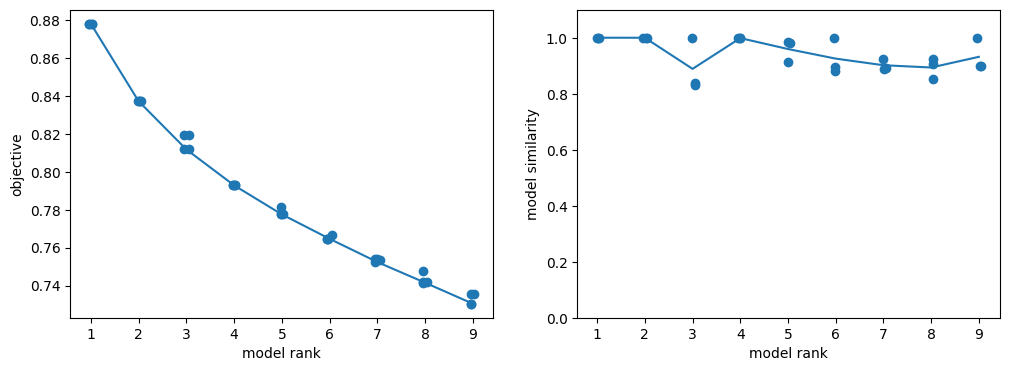

In [ ]:
ranks = range(1, 10) # change to 4 replicas,

ensemble = tt.Ensemble(fit_method="ncp_hals")

ensemble.fit(trial_start_matrix, ranks=ranks, replicates=4)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
tt.plot_objective(ensemble, ax=axes[0])
tt.plot_similarity(ensemble, ax=axes[1])
plt.show()

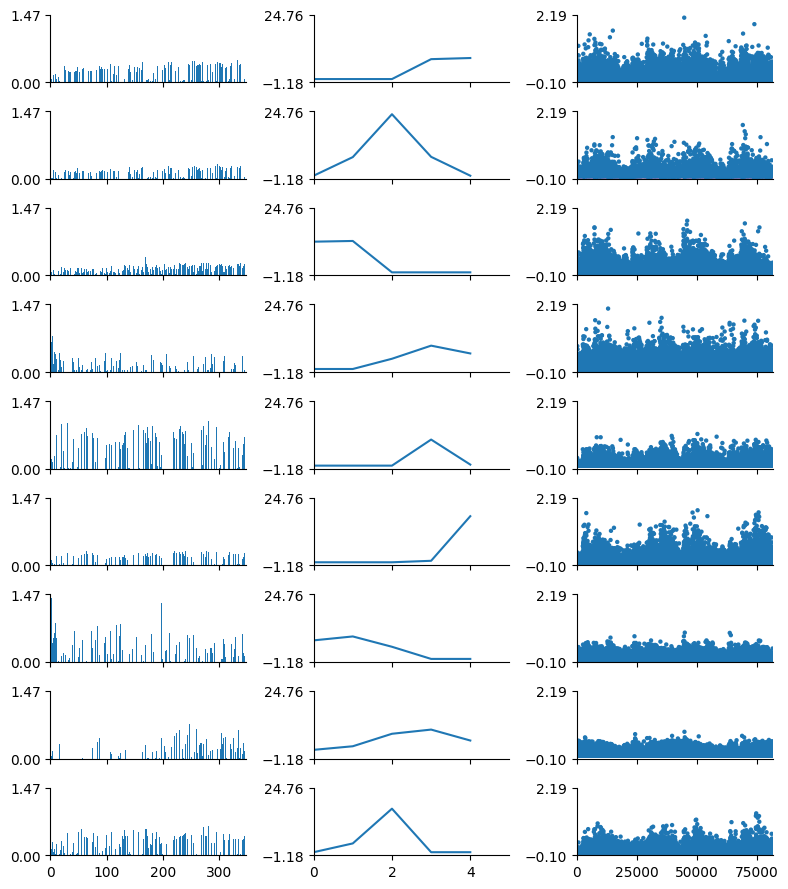

In [ ]:
optimal_rank = 9
replicate = 0
factors = ensemble.factors(optimal_rank)[replicate]
tt.plot_factors(factors, plots=['bar', 'line', 'scatter'],
                # trial_colors=trial_metadata # Optional: color trials by condition
               )
plt.show()

In [ ]:
with open(f'{target_file}.pkl', 'wb') as f:
    pickle.dump(ensemble, f)

## Auto runnnig TCA as batch jobs

In [ ]:
def TCA_auto(target_file, target_path, ranks, replicates, beh_field, buffer):
  '''
  This function automates all of the previous cells, it runs TCA on the target mouse and then saves the TCA ensemble in a pickle file.
  The arguments are:
  target_file: The name of the file that should be used as input
  target_path: The path of the behavioural data
  ranks: The number of ranks for which TCA will be run
  replicates: The number of replicates that will be created during TCA for each rank
  beh_field: The field from beh that will be used as the center for creating the matrix
  buffer: The buffers that will be used around the centre, needs both left nd right buffer
  '''

  # Loading spiking data
  spiking_raw_data = np.load(os.path.join(root, target_file + '_SVD_dec.npy'), allow_pickle=True)

  # Loading behavioural data
  beh = np.load(os.path.join(root, target_path), allow_pickle=1).item()[target_file]

  # Reconstructing spiking data
  spiking_data = spiking_raw_data.item()['U'].T @ spiking_raw_data.item()['V']
  spiking_data = spiking_data.T

  # Correcting for size
  size = min(len(beh['ft']), spiking_data.shape[0])

  # Creating the matrix
  trial_matrix = create_3d_matrix(beh[beh_field], buffer, spiking_data, beh['ft'][:size + 1])

  # Deleting unnecessary objects
  del(spiking_raw_data)
  del(beh)
  del(spiking_data)
  del(size)
  gc.collect()

  # Running TCA
  ranks = range(1, ranks)
  ensemble = tt.Ensemble(fit_method="ncp_hals")
  ensemble.fit(trial_matrix, ranks=ranks, replicates=replicates)

  # Deleting unnecessary objects
  del(trial_matrix)
  gc.collect()

  return ensemble

In [ ]:
TCA_auto(target_file, target_path, 10, 4, "Trial_start_time", (2, 2))

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator TruncatedSVD from version 1.6.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
                                                                    

Rank-1 models:  min obj, 0.88;  max obj, 0.88;  time to fit, 6.5s


Rank-2 models:  min obj, 0.84;  max obj, 0.84;  time to fit, 27.7s


Rank-3 models:  min obj, 0.81;  max obj, 0.82;  time to fit, 53.3s


Rank-4 models:  min obj, 0.79;  max obj, 0.79;  time to fit, 110.6s


Rank-5 models:  min obj, 0.78;  max obj, 0.78;  time to fit, 89.3s


Rank-6 models:  min obj, 0.76;  max obj, 0.77;  time to fit, 127.7s


Rank-7 models:  min obj, 0.75;  max obj, 0.75;  time to fit, 167.9s


Rank-8 models:  min obj, 0.74;  max obj, 0.74;  time to fit, 166.2s


Rank-9 models:  min obj, 0.73;  max obj, 0.74;  time to fit, 158.3s


In [ ]:
# @title Running TCA for all the conditions for both sound cue and trial start time

target_file_list = [sup_bef, sup_aft, unsup_bef, unsup_aft]

for target_file in target_file_list:

  # Select appropriate target file
  if target_file == sup_bef:
    target_path = "Beh_sup_train1_before_learning.npy"
    save_path = "Beh_sup_train1_before_learning_ensemble"
  elif target_file == sup_aft:
    target_path = "Beh_sup_train1_after_learning.npy"
    save_path = "Beh_sup_train1_after_learning_ensemble"
  elif target_file == unsup_bef:
    target_path = "Beh_unsup_train1_before_learning.npy"
    save_path = "Beh_unsup_train1_before_learning_ensemble"
  elif target_file == unsup_aft:
    target_path = "Beh_unsup_train1_after_learning.npy"
    save_path = "Beh_unsup_train1_after_learning_ensemble"

  # Perform TCA and store the file for start time
  start_ensemble = TCA_auto(target_file, target_path, 10, 4, "Trial_start_time", (2, 2))
  joblib.dump(start_ensemble, os.path.join(drive_root, save_path + "_start.joblib"), compress=3)
  del(start_ensemble)
  gc.collect()

  # Perform TCA and store the file for sound time
  sound_ensemble = TCA_auto(target_file, target_path, 10, 4, "SoundTime", (2, 2))
  joblib.dump(sound_ensemble, os.path.join(drive_root, save_path + "_sound.joblib"), compress=3)
  del(sound_ensemble)
  gc.collect()

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator TruncatedSVD from version 1.6.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
                                                                    

Rank-1 models:  min obj, 0.88;  max obj, 0.88;  time to fit, 6.0s


Rank-2 models:  min obj, 0.84;  max obj, 0.84;  time to fit, 27.0s


Rank-3 models:  min obj, 0.81;  max obj, 0.82;  time to fit, 63.7s


Rank-4 models:  min obj, 0.79;  max obj, 0.80;  time to fit, 68.4s


...

Rank-5 models:  min obj, 0.89;  max obj, 0.89;  time to fit, 50.3s


Rank-6 models:  min obj, 0.88;  max obj, 0.88;  time to fit, 57.0s


Rank-7 models:  min obj, 0.87;  max obj, 0.88;  time to fit, 71.9s


Rank-8 models:  min obj, 0.87;  max obj, 0.87;  time to fit, 65.4s


Rank-9 models:  min obj, 0.86;  max obj, 0.87;  time to fit, 77.6s


In [ ]:
aU, aV, aW = factors  # shapes: (n_neurons, R), (n_time, R), (n_trials, R)
R = aU.shape[1]

# Recover ordering used in the tensor from pivot
neuron_order = pivot.index.to_numpy()
frame_labels = pivot.columns.get_level_values(0)
trial_labels = pivot.columns.get_level_values(1)
frame_order = pd.unique(frame_labels)
trial_order = pd.unique(trial_labels).astype(int)

# Metadata maps
neuron_to_area = (
    melted_spikes_start[['neuron', 'area']]
    .drop_duplicates()
    .set_index('neuron')['area']
)
trial_to_stim = (
    melted_spikes_start[['ft_trInd', 'TrialStim']]
    .dropna()
    .drop_duplicates(subset=['ft_trInd'])
    .set_index('ft_trInd')['TrialStim']
)

# Set figure height dynamically relative to number of rows
height_per_row = 2.2  # reasonable height per row (in inches)
fig_height = max(2.5, min(2.2 * R, 18))
fig, axes = plt.subplots(R, 3, figsize=(12, fig_height), sharex=False)
if R == 1:
    axes = np.array([axes])

# Global y-limits per column (neurons/time/trials)
u_min, u_max = round(float(np.nanmin(aU)), 1), round(float(np.nanmax(aU)), 1)
v_min, v_max = round(float(np.nanmin(aV)), 1), round(float(np.nanmax(aV)), 1)
w_min, w_max = round(float(np.nanmin(aW)), 1), round(float(np.nanmax(aW)), 1)

for k in range(R):
    # ---- Neuron scatter (colored by area): x = neuron index, y = loading ----
    ax0 = axes[k, 0]
    neu_df = pd.DataFrame({'neuron': neuron_order, 'loading': aU[:, k]})
    neu_df['area'] = neu_df['neuron'].map(neuron_to_area)
    # sort by area then neuron for a consistent order and build x index
    neu_df = neu_df.sort_values(['area', 'neuron']).reset_index(drop=True)
    neu_df['neuron_idx'] = np.arange(len(neu_df))
    sns.scatterplot(data=neu_df, x='neuron_idx', y='loading', hue='area', s=10, alpha=0.85,
                    ax=ax0, legend=(k == 0))
    ax0.set_title(f'U (neurons) comp {k+1}')
    ax0.set_xlabel('neurons')
    ax0.set_ylabel('')
    ax0.set_ylim(u_min, u_max)
    ax0.set_yticks(np.linspace(u_min, u_max, num=5))
    sns.despine(ax=ax0, top=True, right=True)

    # ---- Time line: x = frame, y = loading ----
    ax1 = axes[k, 1]
    time_df = pd.DataFrame({'frame': frame_order, 'loading': aV[:, k]})
    sns.lineplot(data=time_df, x='frame', y='loading', ax=ax1, color=sns.color_palette('deep')[0], linewidth=2)
    ax1.set_title(f'V (time) comp {k+1}')
    ax1.set_xlabel('time (frames)')
    ax1.set_ylabel('')
    ax1.set_ylim(v_min, v_max)
    ax1.set_yticks(np.linspace(v_min, v_max, num=5))
    sns.despine(ax=ax1, top=True, right=True)

    # ---- Trials scatter (colored by TrialStim): x = ft_trInd, y = loading ----
    ax2 = axes[k, 2]
    tr_df = pd.DataFrame({'ft_trInd': trial_order, 'loading': aW[:, k]})
    tr_df['TrialStim'] = tr_df['ft_trInd'].map(trial_to_stim)
    custom_trialstim_palette = {'circle1': '#DFAE32', 'leaf1': '#02968a'}
    sns.scatterplot(data=tr_df, x='ft_trInd', y='loading', hue='TrialStim', s=10, alpha=0.85,
                    ax=ax2, legend=(k == 0), palette=custom_trialstim_palette)
    ax2.set_title(f'W (trials) comp {k+1}')
    ax2.set_xlabel('trials')
    ax2.set_ylabel('')
    ax2.set_ylim(w_min, w_max)
    ax2.set_yticks(np.linspace(w_min, w_max, num=5))
    sns.despine(ax=ax2, top=True, right=True)

# Place legends nicely only once (first row)
if R >= 1:
    # Move neuron-area legend outside on top right
    leg0 = axes[0, 0].legend(title='area', fontsize=8, loc='upper right', borderaxespad=0.)
    if leg0 is not None:
        axes[0, 0].add_artist(leg0)
    # Move trial-stim legend outside on top right (account for grid col separation)
    leg2 = axes[0, 2].legend(title='TrialStim', fontsize=8, loc='upper right', borderaxespad=0.)
    if leg2 is not None:
        axes[0, 2].add_artist(leg2)

plt.tight_layout()

# Ensure results folder exists
results_dir = "results"
os.makedirs(results_dir, exist_ok=True)
plot_filename = os.path.join(results_dir, "tensor_components_grid_unsupervised_before_unconstraint_cp_als.png")
plt.savefig(plot_filename, dpi=150)
print(f"Plot saved to {plot_filename}")

plt.show()